## Predicting Spotify Streaming Performance

Streaming success is driven by two distinct forces: intrinsic audio qualities (tempo, energy, danceability) and platform distribution (playlist placements, chart appearances). This dataset lets us separate those signals and measure which actually predicts streams.

The target is log1p(streams) rather than raw streams — stream counts are heavily right-skewed with a long tail of viral outliers. Log-transforming compresses that skew, stabilizes variance, and keeps linear model residuals better behaved.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.linear_model import LinearRegression, Ridge, Lasso, ElasticNet
from sklearn.ensemble import RandomForestRegressor
from sklearn.svm import SVR
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.pipeline import Pipeline
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV, KFold
from sklearn.compose import ColumnTransformer
import joblib
import os
from statsmodels.stats.outliers_influence import variance_inflation_factor

In [2]:
df = pd.read_csv('data/Popular_Spotify_Songs.csv', encoding='latin1')
df

,track_name,artist(s)_name,artist_count,released_year,released_month,released_day,in_spotify_playlists,in_spotify_charts,streams,in_apple_playlists,...,key,mode,danceability_%,valence_%,energy_%,acousticness_%,instrumentalness_%,liveness_%,speechiness_%,cover_url
0,Seven (feat. Latto) (Explicit Ver.),"Latto, Jung Kook",2,2023,7,14,553,147,141381703,43,...,B,Major,80,89,83,31,0,8,4,Not Found
1,LALA,Myke Towers,1,2023,3,23,1474,48,133716286,48,...,C#,Major,71,61,74,7,0,10,4,https://i.scdn.co/image/ab67616d0000b2730656d5...
2,vampire,Olivia Rodrigo,1,2023,6,30,1397,113,140003974,94,...,F,Major,51,32,53,17,0,31,6,https://i.scdn.co/image/ab67616d0000b273e85259...
3,Cruel Summer,Taylor Swift,1,2019,8,23,7858,100,800840817,116,...,A,Major,55,58,72,11,0,11,15,https://i.scdn.co/image/ab67616d0000b273e787cf...
4,WHERE SHE GOES,Bad Bunny,1,2023,5,18,3133,50,303236322,84,...,A,Minor,65,23,80,14,63,11,6,https://i.scdn.co/image/ab67616d0000b273ab5c9c...
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
948,My Mind & Me,Selena Gomez,1,2022,11,3,953,0,91473363,61,...,A,Major,60,24,39,57,0,8,3,https://i.scdn.co/image/ab67616d0000b2730f5397...
949,Bigger Than The Whole Sky,Taylor Swift,1,2022,10,21,1180,0,121871870,4,...,F#,Major,42,7,24,83,1,12,6,https://i.scdn.co/image/ab67616d0000b273e0b60c...
950,A Veces (feat. Feid),"Feid, Paulo Londra",2,2022,11,3,573,0,73513683,2,...,C#,Major,80,81,67,4,0,8,6,Not Found
951,En La De Ella,"Feid, Sech, Jhayco",3,2022,10,20,1320,0,133895612,29,...,C#,Major,82,67,77,8,0,12,5,Not Found


## Data Cleaning

Three columns — streams, in_deezer_playlists, in_shazam_charts — arrived as strings with comma separators and occasional dashes in the source CSV. Converted to numeric; dashes treated as 0. The key column had ~10% nulls, filled as "Unknown" to preserve those rows rather than drop them.

In [3]:

df = df.drop_duplicates()

df['released_year'] = df['released_year'].astype(int)
df['released_month'] = df['released_month'].astype(int)
df['released_day'] = df['released_day'].astype(int)

df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 953 entries, 0 to 952
Data columns (total 25 columns):
 #   Column                Non-Null Count  Dtype 
---  ------                --------------  ----- 
 0   track_name            953 non-null    object
 1   artist(s)_name        953 non-null    object
 2   artist_count          953 non-null    int64 
 3   released_year         953 non-null    int64 
 4   released_month        953 non-null    int64 
 5   released_day          953 non-null    int64 
 6   in_spotify_playlists  953 non-null    int64 
 7   in_spotify_charts     953 non-null    int64 
 8   streams               953 non-null    object
 9   in_apple_playlists    953 non-null    int64 
 10  in_apple_charts       953 non-null    int64 
 11  in_deezer_playlists   953 non-null    object
 12  in_deezer_charts      953 non-null    int64 
 13  in_shazam_charts      903 non-null    object
 14  bpm                   953 non-null    int64 
 15  key                   858 non-null    ob

In [4]:

cols_to_fix = ['streams', 'in_deezer_playlists', 'in_shazam_charts']

for col in cols_to_fix:
    df[col] = (
        df[col]
        .astype(str)
        .str.replace(',', '')
        .str.replace(' ', '')
        .str.replace('-', '0')
    )

    df[col] = pd.to_numeric(df[col], errors='coerce')

df['key'] = df['key'].fillna('Unknown')
df[cols_to_fix] = df[cols_to_fix].fillna(0)

df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 953 entries, 0 to 952
Data columns (total 25 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   track_name            953 non-null    object 
 1   artist(s)_name        953 non-null    object 
 2   artist_count          953 non-null    int64  
 3   released_year         953 non-null    int64  
 4   released_month        953 non-null    int64  
 5   released_day          953 non-null    int64  
 6   in_spotify_playlists  953 non-null    int64  
 7   in_spotify_charts     953 non-null    int64  
 8   streams               953 non-null    float64
 9   in_apple_playlists    953 non-null    int64  
 10  in_apple_charts       953 non-null    int64  
 11  in_deezer_playlists   953 non-null    int64  
 12  in_deezer_charts      953 non-null    int64  
 13  in_shazam_charts      953 non-null    float64
 14  bpm                   953 non-null    int64  
 15  key                   9

In [5]:
df['log_streams'] = np.log1p(df['streams'])
df[['streams', 'log_streams']].head()


,streams,log_streams
0,141381703.0,18.766974
1,133716286.0,18.711231
2,140003974.0,18.757181
3,800840817.0,20.501173
4,303236322.0,19.530023


## Features

Two feature sets are defined here. The reason becomes clear after the VIF analysis below — linear models need a reduced set to avoid collinearity problems, while tree-based methods can use everything.

## Preprocessing Pipeline

StandardScaler on numeric features, OneHotEncoder on key and mode. Wrapped in a ColumnTransformer so the same pipeline handles both linear and nonlinear models without leaking preprocessing steps across the train/test split.

In [6]:
numeric_features = [
    'released_year', 'released_month', 'released_day',
    'artist_count',
    'in_spotify_playlists', 'in_spotify_charts',
    'in_apple_playlists', 'in_apple_charts',
    'in_deezer_playlists', 'in_deezer_charts',
    'in_shazam_charts',
    'danceability_%', 'valence_%', 'energy_%',
    'acousticness_%', 'instrumentalness_%',
    'liveness_%', 'speechiness_%',
    'bpm'
]

categorical_features = ['key', 'mode']

X = df[numeric_features + categorical_features]
y = df['log_streams']


In [7]:
preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), numeric_features),
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_features)
    ]
)


## Multicollinearity Analysis

Before fitting linear models, VIF (Variance Inflation Factor) identifies features whose information is already captured by other features. High VIF inflates standard errors and makes linear coefficients unreliable.

released_year came in at VIF ~100 — nearly perfectly collinear with other date features. danceability_% and energy_% also showed high collinearity with bpm. These are dropped from the linear feature set. Tree-based models are unaffected by collinearity so they keep the full feature set.

In [8]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [9]:
X_vif = df[numeric_features].astype(float)

vif_data = pd.DataFrame()
vif_data["feature"] = X_vif.columns
vif_data["VIF"] = [variance_inflation_factor(X_vif.values, i)
                   for i in range(X_vif.shape[1])]

vif_data

,feature,VIF
0,released_year,99.552623
1,released_month,4.128124
2,released_day,3.416574
3,artist_count,4.395215
4,in_spotify_playlists,8.287183
5,in_spotify_charts,3.212234
6,in_apple_playlists,4.648018
7,in_apple_charts,3.555474
8,in_deezer_playlists,3.924573
9,in_deezer_charts,2.202701


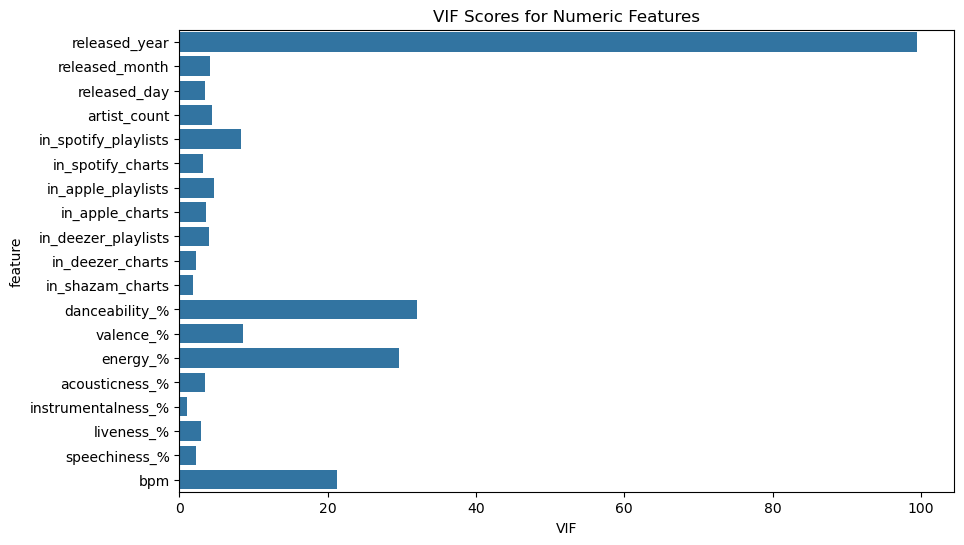

In [10]:
plt.figure(figsize=(10,6))
sns.barplot(data=vif_data, x="VIF", y="feature")
plt.title("VIF Scores for Numeric Features")
plt.show()



In [11]:
df = df.drop(columns=['released_year'])
numeric_features.remove('released_year')


## Modeling

Linear models (Ridge, Lasso, ElasticNet) on the reduced feature set test whether streaming success is linearly predictable from these signals. Nonlinear models (Random Forest, SVR) test whether feature interactions improve prediction — playlist count combined with high danceability may compound in ways a linear model cannot capture.

In [12]:
linear_numeric_features = [
    'released_month', 'released_day',
    'artist_count',
    'in_spotify_playlists', 'in_spotify_charts',
    'in_apple_playlists', 'in_apple_charts',
    'in_deezer_playlists', 'in_deezer_charts',
    'in_shazam_charts',
    'valence_%',
    'acousticness_%', 'instrumentalness_%', 'liveness_%',
    'speechiness_%',
]


In [13]:
linear_categorical_features = ['key', 'mode']


In [14]:
linear_preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), linear_numeric_features),
        ("cat", OneHotEncoder(handle_unknown='ignore'), linear_categorical_features)
    ]
)


In [15]:
nonlinear_preprocessor = preprocessor


In [16]:
lr_model = Pipeline(steps=[
    ("preprocessor", linear_preprocessor),
    ("regressor", LinearRegression())
])
lr_model.fit(X_train[linear_numeric_features + linear_categorical_features], y_train)
lr_pred = lr_model.predict(X_test[linear_numeric_features + linear_categorical_features])


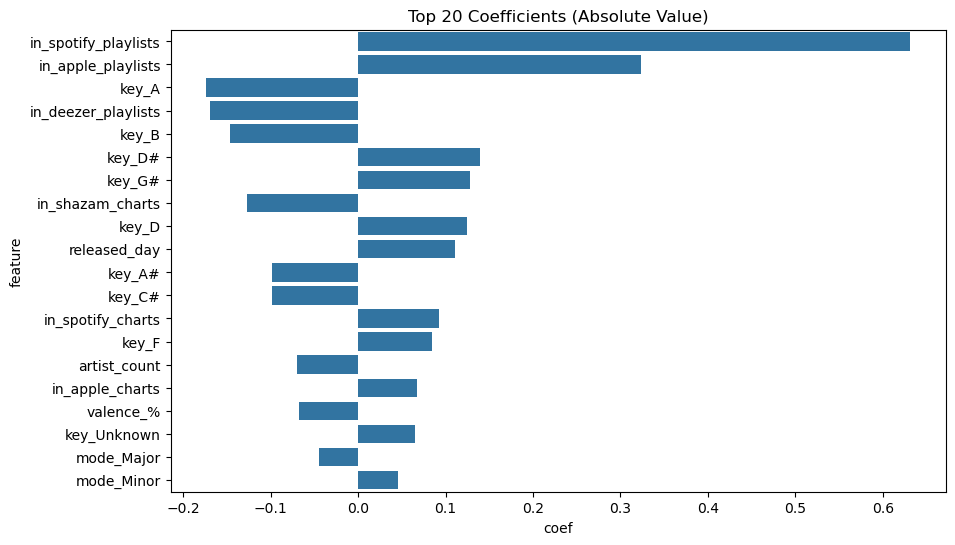

In [17]:
lin = lr_model.named_steps["regressor"]
enc = lr_model.named_steps["preprocessor"].named_transformers_["cat"]
ohe_features = enc.get_feature_names_out(linear_categorical_features)

all_features = linear_numeric_features + list(ohe_features)
coef = lin.coef_

coef_df = pd.DataFrame({"feature": all_features, "coef": coef})
coef_df = coef_df.sort_values("coef", key=abs, ascending=False).head(20)

plt.figure(figsize=(10,6))
sns.barplot(data=coef_df, x="coef", y="feature")
plt.title("Top 20 Coefficients (Absolute Value)")
plt.show()


In [18]:
elastic_model = Pipeline(steps=[
    ("preprocessor", linear_preprocessor),
    ("regressor", ElasticNet(alpha=0.1, l1_ratio=0.5, max_iter=5000))
])
elastic_model.fit(X_train[linear_numeric_features + linear_categorical_features], y_train)
elastic_pred = elastic_model.predict(X_test[linear_numeric_features + linear_categorical_features])


In [19]:
rf_model = Pipeline(steps=[
    ("preprocessor", nonlinear_preprocessor),
    ("regressor", RandomForestRegressor(n_estimators=500, random_state=19))
])
rf_model.fit(X_train, y_train)
rf_pred = rf_model.predict(X_test)


In [20]:
svr_model = Pipeline(steps=[
    ("preprocessor", nonlinear_preprocessor),
    ("regressor", SVR(kernel='rbf', C=10, gamma='scale'))
])
svr_model.fit(X_train, y_train)
svr_pred = svr_model.predict(X_test)

In [21]:
results = pd.DataFrame([
    ["Linear Regression",
     np.sqrt(mean_squared_error(y_test, lr_pred)),
     mean_absolute_error(y_test, lr_pred),
     r2_score(y_test, lr_pred)],

    ["Elastic Net",
     np.sqrt(mean_squared_error(y_test, elastic_pred)),
     mean_absolute_error(y_test, elastic_pred),
     r2_score(y_test, elastic_pred)],

    ["Random Forest",
     np.sqrt(mean_squared_error(y_test, rf_pred)),
     mean_absolute_error(y_test, rf_pred),
     r2_score(y_test, rf_pred)],

    ["SVR",
     np.sqrt(mean_squared_error(y_test, svr_pred)),
     mean_absolute_error(y_test, svr_pred),
     r2_score(y_test, svr_pred)]
], columns=["Model", "RMSE", "MAE", "R²"])

results.sort_values("RMSE")


,Model,RMSE,MAE,R²
2,Random Forest,0.515904,0.403071,0.736349
3,SVR,0.662598,0.528686,0.565098
1,Elastic Net,0.718539,0.588660,0.488563
0,Linear Regression,0.722747,0.577396,0.482557


In [22]:
param_grid_rf_fast = {
    "regressor__n_estimators": [200, 400],
    "regressor__max_depth": [15, None],
    "regressor__min_samples_split": [2, 10]
}


In [23]:
kf = KFold(n_splits=3, shuffle=True, random_state=42)

NameError: name 'KFold' is not defined

## Hyperparameter Tuning

GridSearchCV with 3-fold cross-validation over n_estimators, max_depth, and min_samples_split. With only 953 rows, unconstrained trees overfit easily — the search is designed to find the right depth constraint rather than just maximize tree count.

In [ ]:
df_small = df.sample(frac=0.6, random_state =42)
X_small = df_small.drop("log_streams", axis=1)
y_small = df_small["log_streams"]


In [ ]:
X_encoded = nonlinear_preprocessor.fit_transform(X)


In [ ]:
from sklearn.model_selection import GridSearchCV, KFold

param_grid_rf_fast = {
    "regressor__n_estimators": [200, 400],
    "regressor__max_depth": [15,    None],
    "regressor__min_samples_split": [2, 10]
}

kf = KFold(n_splits=3, shuffle=True, random_state=42)

rf_pipeline = Pipeline(steps=[
    ("preprocessor", nonlinear_preprocessor),
    ("regressor", RandomForestRegressor(random_state=42))
])

rf_grid = GridSearchCV(
    rf_pipeline,
    param_grid_rf_fast,
    scoring="neg_root_mean_squared_error",
    cv=kf,
    n_jobs=-1
)

rf_grid.fit(X_train, y_train)
best_rf = rf_grid.best_estimator_

rf_pred = best_rf.predict(X_test)

print("Best params:", rf_grid.best_params_)
print("RMSE:", np.sqrt(mean_squared_error(y_test, rf_pred)))
print("R2:", r2_score(y_test, rf_pred))


In [ ]:
rf_reg = best_rf.named_steps["regressor"]
importances = rf_reg.feature_importances_

feat_names = best_rf.named_steps["preprocessor"].get_feature_names_out()

imp_df = pd.DataFrame({"feature": feat_names, "importance": importances})
imp_df = imp_df.sort_values("importance", ascending=False)

plt.figure(figsize=(10,6))
sns.barplot(data=imp_df.head(15), x="importance", y="feature")
plt.title("Top 15 Feature Importances — Tuned Random Forest")
plt.show()


In [ ]:
pred = best_rf.predict(X_test)
resid = y_test - pred

sns.scatterplot(x=pred, y=resid)
plt.axhline(0, color='red')
plt.title("Residual Plot — Tuned RF")
plt.xlabel("Predicted log-streams")
plt.ylabel("Residuals")


## Error Analysis

The residual plot and per-artist MAE breakdown reveal where the model systematically fails. Songs with the highest stream counts are consistently underpredicted — the model has no visibility into TikTok virality, film/TV sync placements, or radio rotation, which are the real drivers of outlier numbers.

In [ ]:

X_train_raw, X_test_raw, y_train, y_test = train_test_split(
    df.drop(columns=["log_streams"]),
    df["log_streams"],
    test_size=0.2,
    random_state=42
)

pred = best_rf.predict(X_test)

df_test = X_test_raw.copy()
df_test["true"] = y_test
df_test["pred"] = pred
df_test["error"] = abs(df_test["true"] - df_test["pred"])

df_test["is_taylor"] = df_test["artist(s)_name"].str.contains("Taylor Swift", case=False)

df_test.groupby("is_taylor")["error"].mean()


In [ ]:
major_artists = [
 'Taylor Swift',
 'The Weeknd',
 'SZA',
 'Bad Bunny',
 'Harry Styles',
 'Kendrick Lamar',
 'Morgan Wallen',
 'Ed Sheeran',
 'BTS',
 'Feid',
 'Drake, 21 Savage',
 'Olivia Rodrigo',
 'Labrinth',
 'Doja Cat',
 'NewJeans',
 'Billie Eilish'
]


In [ ]:
df_test = X_test_raw.copy()
df_test["true"] = y_test
df_test["pred"] = best_rf.predict(X_test)
df_test["error"] = abs(df_test["true"] - df_test["pred"])

def clean_name(name):
    return name.replace(" ", "_").replace(",", "").replace(".", "")

for artist in major_artists:
    cleaned = clean_name(artist)
    df_test[f"is_{cleaned}"] = df_test["artist(s)_name"].str.contains(artist, case=False)


In [ ]:
artist_errors = {}

for artist in major_artists:
    mask = df_test["artist(s)_name"].str.contains(artist, case=False)

    if mask.sum() == 0:
        continue

    mae = df_test.loc[mask, "error"].mean()
    artist_errors[artist] = mae

artist_errors_df = (
    pd.DataFrame.from_dict(artist_errors, orient="index", columns=["MAE"])
    .sort_values("MAE")
)

artist_errors_df


In [ ]:
plt.figure(figsize=(10, 6))
sns.barplot(
    data=artist_errors_df.reset_index(),
    x="MAE",
    y="index",
    palette="viridis"
)
plt.xlabel("Mean Absolute Error (log-streams)")
plt.ylabel("Artist")
plt.title("Random Forest Prediction Error by Artist")
plt.show()


In [ ]:
selected = artist_errors_df.index.tolist()

plt.figure(figsize=(12, 6))
sns.boxplot(
    data=df_test[df_test["artist(s)_name"].isin(selected)],
    x="artist(s)_name",
    y="error"
)
plt.xticks(rotation=45)
plt.title("Distribution of Prediction Error by Artist")
plt.ylabel("Absolute Error")
plt.show()


In [ ]:
os.makedirs("model", exist_ok=True)
joblib.dump(best_rf, "model/rf_pipeline.pkl")
print("Model saved to model/rf_pipeline.pkl")